# Regression Trees — Combined Cycle Power Plant Dataset

This notebook demonstrates regression trees on the UCI Combined Cycle Power Plant dataset and compares them with OLS linear regression. By the end you will be able to:

- Train a regression tree and evaluate it with R², MSE, and MAE
- Observe the variance-bias trade-off by sweeping `max_depth`
- Compare tree-based regression with linear regression in a side-by-side summary table
- Inspect the residual distribution to assess model quality

## Mathematical Intuition

A **regression tree** recursively partitions the feature space into rectangular regions and predicts the mean target value within each region.

At each node, the algorithm selects the feature $j$ and threshold $t$ that maximise the **variance reduction** (equivalent to minimising MSE):

$$\text{Gain} = \text{Var}(\text{parent}) - \frac{n_L}{n}\,\text{Var}(L) - \frac{n_R}{n}\,\text{Var}(R)$$

where $\text{Var}(\mathcal{S}) = \frac{1}{|\mathcal{S}|} \sum_{i \in \mathcal{S}} (y_i - \bar{y}_{\mathcal{S}})^2$ is the variance of the target within region $\mathcal{S}$.

**Shallow trees** (small `max_depth`) produce a small number of large regions — high bias, low variance. **Deep trees** create many small regions — low bias, high variance (they can memorise training noise). `max_depth` is the primary regularisation knob.

## Dataset Overview

| Feature | Type | Description |
|---------|------|-------------|
| AT | Continuous | Ambient temperature (°C) |
| V  | Continuous | Exhaust vacuum (cm Hg) |
| AP | Continuous | Ambient pressure (mbar) |
| RH | Continuous | Relative humidity (%) |
| **PE** | **Continuous** | **Net hourly electrical energy output (MW) — target** |

- **Rows:** 9,568 | **Features:** 4 | **Missing values:** none

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from mlpackage import (
    RegressionTree, LinearRegression,
    StandardScaler, train_test_split,
    mean_squared_error, mean_absolute_error, r2_score,
)

sns.set_style("whitegrid")

ccpp = fetch_ucirepo(id=294)
X_raw = ccpp.data.features.values.astype(float)
y_raw = ccpp.data.targets.values.ravel().astype(float)
feature_names = list(ccpp.data.features.columns)

print("Features shape:", X_raw.shape)
print("Target shape:  ", y_raw.shape)

Features shape: (9568, 4)
Target shape:   (9568,)


## Exploratory Data Analysis

In [2]:
df = pd.DataFrame(X_raw, columns=feature_names)
df["PE"] = y_raw
print("Descriptive statistics:")
df.describe()

Descriptive statistics:


,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


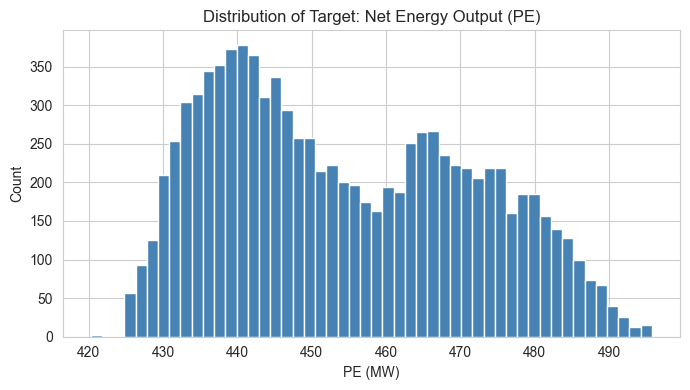

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(y_raw, bins=50, color="steelblue", edgecolor="white")
ax.set_title("Distribution of Target: Net Energy Output (PE)")
ax.set_xlabel("PE (MW)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

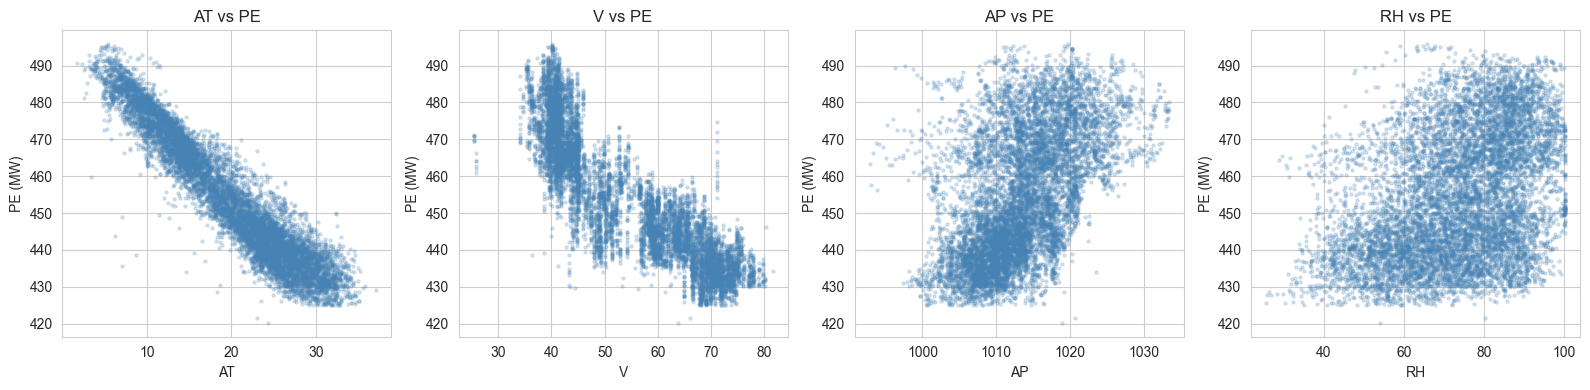

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, feature_names):
    ax.scatter(df[col], y_raw, alpha=0.2, s=5, color="steelblue")
    ax.set_title(f"{col} vs PE")
    ax.set_xlabel(col)
    ax.set_ylabel("PE (MW)")
plt.tight_layout()
plt.show()

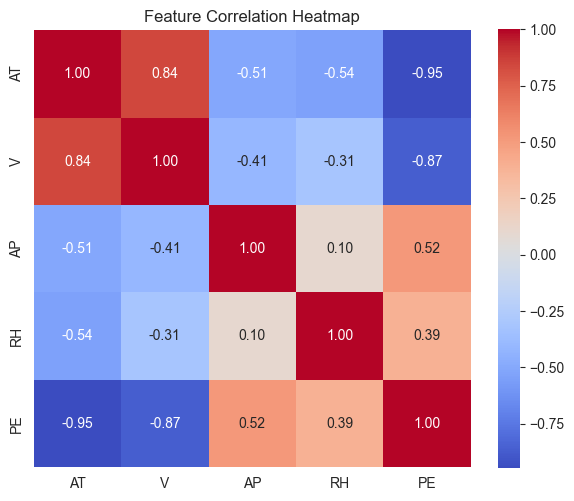

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax, square=True)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Preprocessing

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# RegressionTree does not require scaling, but LinearRegression benefits from it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

Train size: 7654  |  Test size: 1914


## Model Training

In [7]:
tree = RegressionTree(max_depth=5)
tree.fit(X_train, y_train)

train_r2 = tree.score(X_train, y_train)
test_r2  = tree.score(X_test,  y_test)
test_mse = mean_squared_error(y_test, tree.predict(X_test))
test_mae = mean_absolute_error(y_test, tree.predict(X_test))

print(f"Train R2: {train_r2:.4f}  |  Test R2: {test_r2:.4f}")
print(f"Test MSE: {test_mse:.4f}  |  Test MAE: {test_mae:.4f}")

Train R2: 0.9361  |  Test R2: 0.9343
Test MSE: 19.0834  |  Test MAE: 3.3856


max_depth=1     Train R2: 0.7182  |  Test R2: 0.7308
max_depth=2     Train R2: 0.8605  |  Test R2: 0.8680
max_depth=3     Train R2: 0.9096  |  Test R2: 0.9123
max_depth=5     Train R2: 0.9361  |  Test R2: 0.9343
max_depth=8     Train R2: 0.9578  |  Test R2: 0.9433
max_depth=15    Train R2: 0.9886  |  Test R2: 0.9375
max_depth=None  Train R2: 0.9923  |  Test R2: 0.9373

Best test R2 at max_depth=8: 0.9433


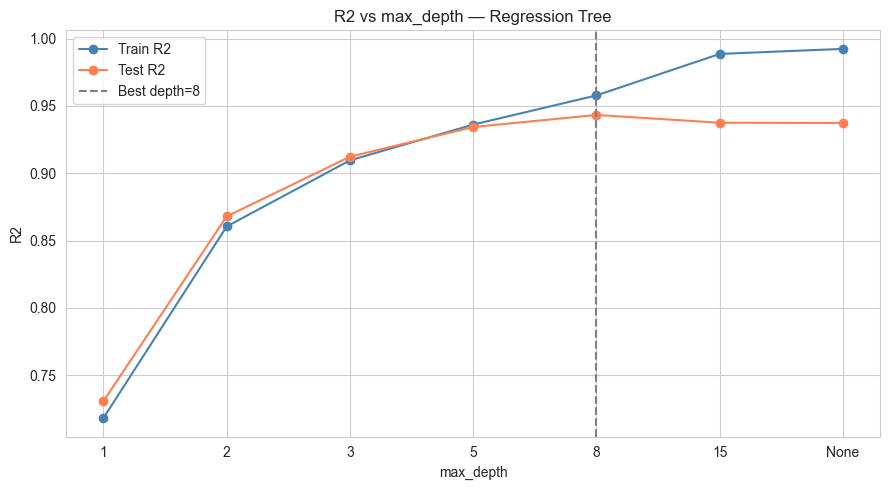

In [8]:
# Depth sweep
depths      = [1, 2, 3, 5, 8, 15, None]
depth_labels = [str(d) for d in depths]
train_r2s    = []
test_r2s     = []

for d in depths:
    t = RegressionTree(max_depth=d)
    t.fit(X_train, y_train)
    train_r2s.append(t.score(X_train, y_train))
    test_r2s.append(t.score(X_test,   y_test))
    print(f"max_depth={str(d):4s}  Train R2: {train_r2s[-1]:.4f}  |  Test R2: {test_r2s[-1]:.4f}")

best_idx   = int(np.argmax(test_r2s))
best_depth = depths[best_idx]
print(f"\nBest test R2 at max_depth={best_depth}: {test_r2s[best_idx]:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depth_labels, train_r2s, marker="o", label="Train R2", color="steelblue")
ax.plot(depth_labels, test_r2s,  marker="o", label="Test R2",  color="coral")
ax.axvline(x=depth_labels[best_idx], color="gray", linestyle="--",
           label=f"Best depth={best_depth}")
ax.set_title("R2 vs max_depth — Regression Tree")
ax.set_xlabel("max_depth")
ax.set_ylabel("R2")
ax.legend()
plt.tight_layout()
plt.show()

## Evaluation

In [9]:
# Best regression tree
best_tree = RegressionTree(max_depth=best_depth)
best_tree.fit(X_train, y_train)
y_pred_tree = best_tree.predict(X_test)

# OLS linear regression for comparison
ols = LinearRegression(solver="ols")
ols.fit(X_train_scaled, y_train)
y_pred_ols = ols.predict(X_test_scaled)

summary = pd.DataFrame({
    "Model":    [f"RegressionTree (max_depth={best_depth})", "LinearRegression (OLS)"],
    "Test R2":  [round(r2_score(y_test, y_pred_tree), 4), round(r2_score(y_test, y_pred_ols), 4)],
    "Test MSE": [round(mean_squared_error(y_test, y_pred_tree), 4), round(mean_squared_error(y_test, y_pred_ols), 4)],
    "Test MAE": [round(mean_absolute_error(y_test, y_pred_tree), 4), round(mean_absolute_error(y_test, y_pred_ols), 4)],
}).set_index("Model")
print(summary.to_string())

                              Test R2  Test MSE  Test MAE
Model                                                    
RegressionTree (max_depth=8)   0.9433   16.4844    3.0704
LinearRegression (OLS)         0.9311   20.0303    3.6240


## Visualisations

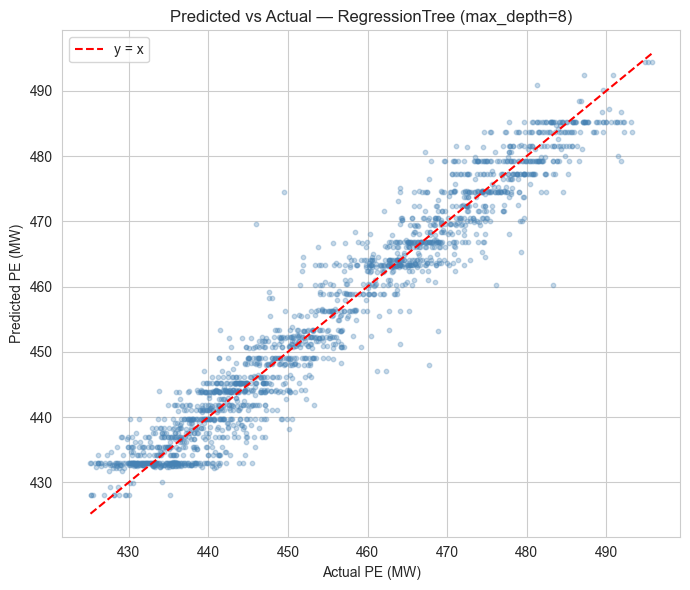

In [10]:
# Predicted vs actual scatter for best tree
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_tree, alpha=0.3, s=10, color="steelblue")
lims = [min(y_test.min(), y_pred_tree.min()), max(y_test.max(), y_pred_tree.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="y = x")
ax.set_title(f"Predicted vs Actual — RegressionTree (max_depth={best_depth})")
ax.set_xlabel("Actual PE (MW)")
ax.set_ylabel("Predicted PE (MW)")
ax.legend()
plt.tight_layout()
plt.show()

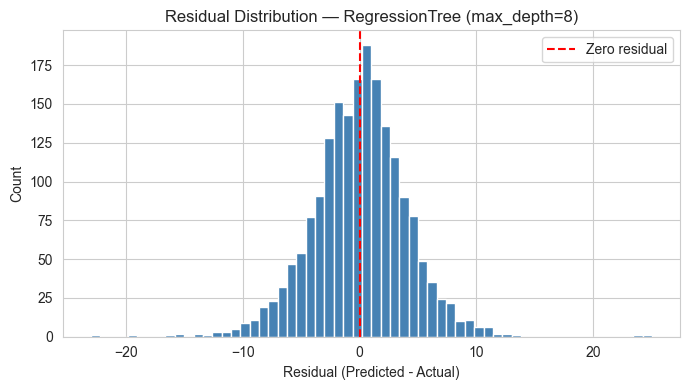

Residual mean: -0.0027  |  Residual std: 4.0601


In [11]:
# Residual distribution
residuals = y_pred_tree - y_test

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(residuals, bins=60, color="steelblue", edgecolor="white")
ax.axvline(0, color="red", linewidth=1.5, linestyle="--", label="Zero residual")
ax.set_title(f"Residual Distribution — RegressionTree (max_depth={best_depth})")
ax.set_xlabel("Residual (Predicted - Actual)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.4f}  |  Residual std: {residuals.std():.4f}")

## Interpretation and Conclusions

### Model Architecture: Strengths and Weaknesses

- A **regression tree** recursively partitions the feature space into axis-aligned rectangular regions, predicting the mean target value within each region.
- Architectural strengths: **no distributional assumptions**, can capture interactions between variables, and is **invariant to monotone feature transformations** (standardisation not required).
- The dominant weakness is the **piecewise constant prediction function**: within each leaf the model outputs a single constant, so smooth curvature in the true relationship can only be approximated by creating many small leaves.
- This makes the model **unstable with respect to `max_depth`**: too shallow produces high bias; too deep memorises training noise (high variance).

### Why It Outperformed OLS on This Dataset

- The **depth sweep** reveals that the regression tree at depth 8 achieves **test $R^2 = 0.9433$**, outperforming OLS linear regression (test $R^2 = 0.9311$): a reduction in MSE from **20.03 to 16.48** and MAE from **3.62 to 3.07** MW.
- The improvement reflects **mild non-linear curvature** in the AT-PE relationship: a global linear coefficient cannot represent it, but the tree captures it through finer partitioning near the extremes of the temperature range.
- Beyond depth 8, **train $R^2$ continues rising** (reaching 0.9886 at depth 15) while **test $R^2$ falls** back toward 0.9373: the unconstrained tree memorises the training set at the cost of generalisation.
- The **optimal depth of 8** sits at the elbow where variance reduction on the training set no longer translates to gains on held-out data.

### Results Grounded in the Graphs

- The **depth-vs-$R^2$ plot** shows both lines improving together for depths 1-5, then diverging after depth 8 as the train curve continues upward while the test curve flattens and turns over.
- The **predicted-vs-actual scatter** at depth 8 shows a tight cluster around the $y = x$ diagonal with a faint staircase pattern corresponding to leaf means, which is imperceptible at this depth.
- The **residual histogram** is approximately bell-shaped and centred near zero (mean **-0.003**, std **4.06 MW**), confirming no systematic over- or under-prediction.
- The **smaller residual standard deviation** compared to OLS (approximately 4.5 MW) is consistent with the lower MSE of the regression tree.